# Contour Detection

A contour is directed curve joining all continuous points along a boundary that share the exact same color or intensity. It is different than edges, since edges are areas where pixel brightness changes abruptly (local gradients) which are messy and fragmented. 

A contour is completed, continious line wrapping around the object.

- useful tools in shape analysis, object detection and recognition

```TEXT

Contours are found accurately on binary images (black and white only where the object is pure white and the background is pure black).

[Original BGR Image] 
         ↓
[Grayscale Conversion] (Removes color noise)
         ↓
[Threshold / Canny Edge] (Turns image into Binary: 0 or 255)
         ↓
[findContours()] (Extracts the geometric coordinates)


3 contours found


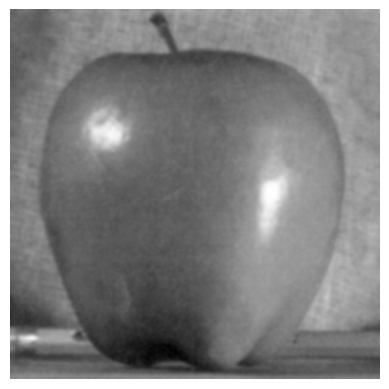

In [6]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


img=cv.imread("image/apple.jpg")
gray=cv.cvtColor(img,cv.COLOR_BGR2GRAY)
blur=cv.GaussianBlur(gray,(5,5),cv.BORDER_DEFAULT)
canny=cv.Canny(blur,125,175)  #125 and 175 are thresholds




# Below line finds every individual shape boundary (cv.RETR_LIST) from the edge-detected image without compressing any pixel coordinates (cv.CHAIN_APPROX_NONE), 
# saving the geometric boundary coordinates into contours and their organizational relationships into hierarchies.

contours,hierarchies=cv.findContours(canny,cv.RETR_LIST,cv.CHAIN_APPROX_SIMPLE)
print(f"{len(contours)} contours found")


plt.imshow(blur,cmap="gray")
plt.axis("off")
plt.show()

```TEXT

Pixel Gradient Intensity
                  │
        [ > 175 (Upper) ]  ─────────►  STRONG EDGE (Always Kept)
                  │
   [ Between 125 and 175 ]  ─────────►  WEAK EDGE   (Kept ONLY if connected to a Strong Edge)
                  │
        [ < 125 (Lower) ]  ─────────►  NOISE       (Always Discarded)
```

Contour Retrieval Modes (`cv.findContours`)

| Retrieval Mode | What It Detects | Hierarchy Relationship | Best Used For |
| :--- | :--- | :--- | :--- |
| **`cv.RETR_EXTERNAL`** | Extreme **outer boundaries** only. | None (ignores all internal shapes). | Object tracking, simple shape isolation. |
| **`cv.RETR_LIST`** | **All contours** found in the image. | Flat list (no parent-child connections). | Counting items, calculating total area. |
| **`cv.RETR_CCOMP`** | **All contours**. | Strict **2-layer system** (Exterior vs. Interior holes). | OCR / Text analysis (separating letters from holes). |
| **`cv.RETR_TREE`** | **All contours**. | Full **family tree** (Parents $\rightarrow$ Children $\rightarrow$ Grandchildren). | Complex nested shapes, full scene structural analysis. |

 Summary: Contour Approximation Modes (`cv.findContours`)

The **Contour Approximation Mode** flag determines how many boundary points OpenCV saves in memory when mapping out a shape. It balances mathematical precision against computational efficiency.

| Approximation Mode | How it Works | Data Footprint | Best Used For |
| :--- | :--- | :--- | :--- |
| **`cv.CHAIN_APPROX_NONE`** | Stores **every single pixel coordinate** along the boundary line. No compression. | 🔴 **High** (Large memory usage) | Organic or highly complex shapes where every minor curve matters. |
| **`cv.CHAIN_APPROX_SIMPLE`** | Compresses horizontal, vertical, and diagonal segments. It **only keeps the vital endpoints/vertex points** (e.g., a perfect rectangle drops from hundreds of points down to just its 4 corners). | 🟢 **Low** (Massive memory savings) | Standard geometric shapes, real-time tracking, or optimizing performance. |

---

###  Visualizing the Difference

Imagine a straight boundary line that is **100 pixels long**:
* **`cv.CHAIN_APPROX_NONE`** will save all **100 points** sequentially in memory.
* **`cv.CHAIN_APPROX_SIMPLE`** will only save **2 points** (the start point and the end point) because it knows a straight line can be perfectly reconstructed with just its endpoints.

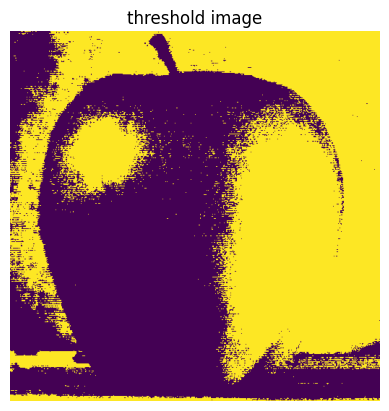

2031 contours found


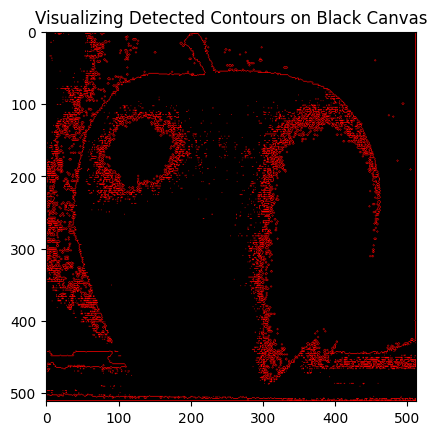

In [20]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt


img=cv.imread("image/apple.jpg")
blank=np.zeros(img.shape,dtype="uint8")


gray=cv.cvtColor(img,cv.COLOR_BGR2GRAY)
ret,thresh=cv.threshold(gray,125,255,cv.THRESH_BINARY)
plt.title("threshold image")
plt.imshow(thresh)
plt.axis("off")
plt.show()

contours,hierarchies=cv.findContours(thresh,cv.RETR_LIST,cv.CHAIN_APPROX_SIMPLE)
print(f"{len(contours)} contours found")
cv.drawContours(blank,contours, -1, (0,0,255),1)
# Convert BGR to RGB so Matplotlib shows the correct colors
blank_rgb = cv.cvtColor(blank, cv.COLOR_BGR2RGB)
plt.title("Visualizing Detected Contours on Black Canvas")
plt.imshow(blank_rgb)
plt.show()


# plt.imshow(blur,cmap="gray")
# plt.axis("off")
# plt.show()